# talsim tutorial: tax-aware long-short simulation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/engineerinvestor/talsim/blob/master/examples/talsim_tutorial.ipynb)

`talsim` simulates a tax-aware long-short (TALS) portfolio on a synthetic market: lot-level tax accounting with enforced wash sales, financing and trading costs, margin response, and a terminal liquidation, repeated over Monte Carlo paths. The question it exists to answer is when additional long-short leverage creates usable after-tax value and when it mostly creates turnover, cost, risk, and deferred tax. This notebook walks through the public API in about a minute of compute.

> **Research software, not advice.** The market is synthetic and the tax accounting is a documented approximation. Every number here is conditional on the stated assumptions and is not evidence about any real strategy. The path counts below are small, so the numbers are illustrative; the official results in the README come from 200 paths generated in pinned CI. Do not use any of this for personal financial decisions.

## Setup

On Colab this installs `pytalsim` from PyPI (the import name is still `talsim`). In a local checkout with `pip install -e .` the import succeeds and the install line is skipped.

In [ ]:
try:
    import talsim
except ImportError:
    %pip install -q "pytalsim[plot]"
    import talsim

print("talsim", talsim.__version__)

talsim 0.4.0


## 1. One config, one path

`ScenarioConfig` holds every assumption: $1M starting capital, 10 years, quarterly rebalancing, 36 assets, zero alpha, top 2026 federal rates, and $100k per year of outside short-term gains to absorb harvested losses. `run_path` simulates a single seeded path and returns a `PathResult`.

In [ ]:
import dataclasses

import pandas as pd

from talsim import ScenarioConfig, run_path

cfg = ScenarioConfig()
pd.Series(dataclasses.asdict(cfg), name="default config")

starting_capital                 1000000.0
years                                   10
steps_per_year                           4
n_assets                                36
n_sectors                                4
market_drift                          0.06
market_vol                            0.16
sector_vol                            0.08
idio_vol                              0.25
dividend_yield                       0.013
signal_autocorr                        0.9
long_exposure                          1.0
short_exposure                         0.0
alpha_annual                           0.0
alpha_reference_active_gross           1.0
st_rate                              0.408
lt_rate                              0.238
ordinary_rate                        0.408
ordinary_offset_limit               3000.0
outside_st_gains_annual           100000.0
outside_st_gain_events                  {}
management_fee                      0.0045
borrow_cost                         0.0075
transaction

In [ ]:
result = run_path(cfg, seed=7)

key_fields = [
    "ending_after_tax_wealth",
    "after_tax_cagr",
    "tracking_error",
    "max_drawdown",
    "annual_turnover",
    "avg_long_exposure",
    "avg_short_exposure",
    "management_fees",
    "borrow_costs",
    "transaction_costs",
]
pd.Series({name: getattr(result, name) for name in key_fields}, name="100/0, seed 7")

ending_after_tax_wealth    1.175866e+06
after_tax_cagr             1.633245e-02
tracking_error             2.599698e-02
max_drawdown              -3.360103e-01
annual_turnover            7.184214e-01
avg_long_exposure          1.044096e+00
avg_short_exposure         0.000000e+00
management_fees            4.799712e+04
borrow_costs               0.000000e+00
transaction_costs          8.795850e+03
Name: 100/0, seed 7, dtype: float64

## 2. Five accounting quantities, and why more losses is not more wealth

The reports keep these separate on purpose. Gross losses realized is the headline number most harvesting pitches quote. Only `tax_benefit_used` is household tax actually saved (against outside gains plus the $3,000 ordinary offset), and `liquidation_tax` is the deferred tax that comes due at the terminal unwind. Losses the ledger disallowed under the wash-sale rule are not lost; their value moved into replacement basis.

In [ ]:
accounting = [
    "gross_losses_realized",
    "disallowed_wash_losses",
    "net_realized_pre_liquidation",
    "tax_benefit_used",
    "liquidation_tax",
    "unused_loss_carry",
]
pd.Series({name: getattr(result, name) for name in accounting}, name="100/0, seed 7").round(0)

gross_losses_realized           868984.0
disallowed_wash_losses               0.0
net_realized_pre_liquidation   -276073.0
tax_benefit_used                134076.0
liquidation_tax                  98282.0
unused_loss_carry                   -0.0
Name: 100/0, seed 7, dtype: float64

## 3. Leverage sweep on common random numbers

`run_sweep` runs each book preset over the same seeds (path `p` uses seed `base_seed + p` for every book), so differences between books are paired rather than confounded by different market draws. `summarize` reports p10, median, and p90 per book plus two paired columns: `wealth_diff_vs_baseline_median` is the median of per-path wealth differences against the first book, and `prob_beats_baseline` is the fraction of paths on which the book ends wealthier than that baseline. 40 paths is enough to see the pattern; the README figure uses 200.

In [ ]:
from talsim import run_sweep
from talsim.cli import summarize

books = ["100/0", "130/30", "150/50"]
sweeps = run_sweep(cfg, books, n_paths=40, base_seed=7)

columns = [
    "gross_exposure",
    "ending_after_tax_wealth_p10",
    "ending_after_tax_wealth_median",
    "ending_after_tax_wealth_p90",
    "gross_losses_realized_median",
    "tax_benefit_used_median",
    "liquidation_tax_median",
    "wealth_diff_vs_baseline_median",
    "prob_beats_baseline",
    "maintenance_deficiency_probability",
]
summary = summarize(sweeps).set_index("book")
summary[columns].round(2).T

book,100/0,130/30,150/50
gross_exposure,1.00,1.60,2.00
ending_after_tax_wealth_p10,950267.38,907818.73,864498.34
ending_after_tax_wealth_median,1640928.24,1562301.51,1363019.19
ending_after_tax_wealth_p90,2672940.61,2438724.95,2414271.92
gross_losses_realized_median,758892.39,2478801.75,3193081.96
tax_benefit_used_median,109473.01,166089.34,191486.16
liquidation_tax_median,185389.09,119421.59,120961.87
wealth_diff_vs_baseline_median,0.00,-78901.97,-155936.61
prob_beats_baseline,0.00,0.28,0.18
maintenance_deficiency_probability,0.00,0.00,0.00


## 4. The report figure

`talsim.plotting.four_panel` draws the same four panels as the README figure from a list of `SweepResult`s. It saves a PNG with the Agg backend rather than returning a figure, so we write to a temporary path and display the file.

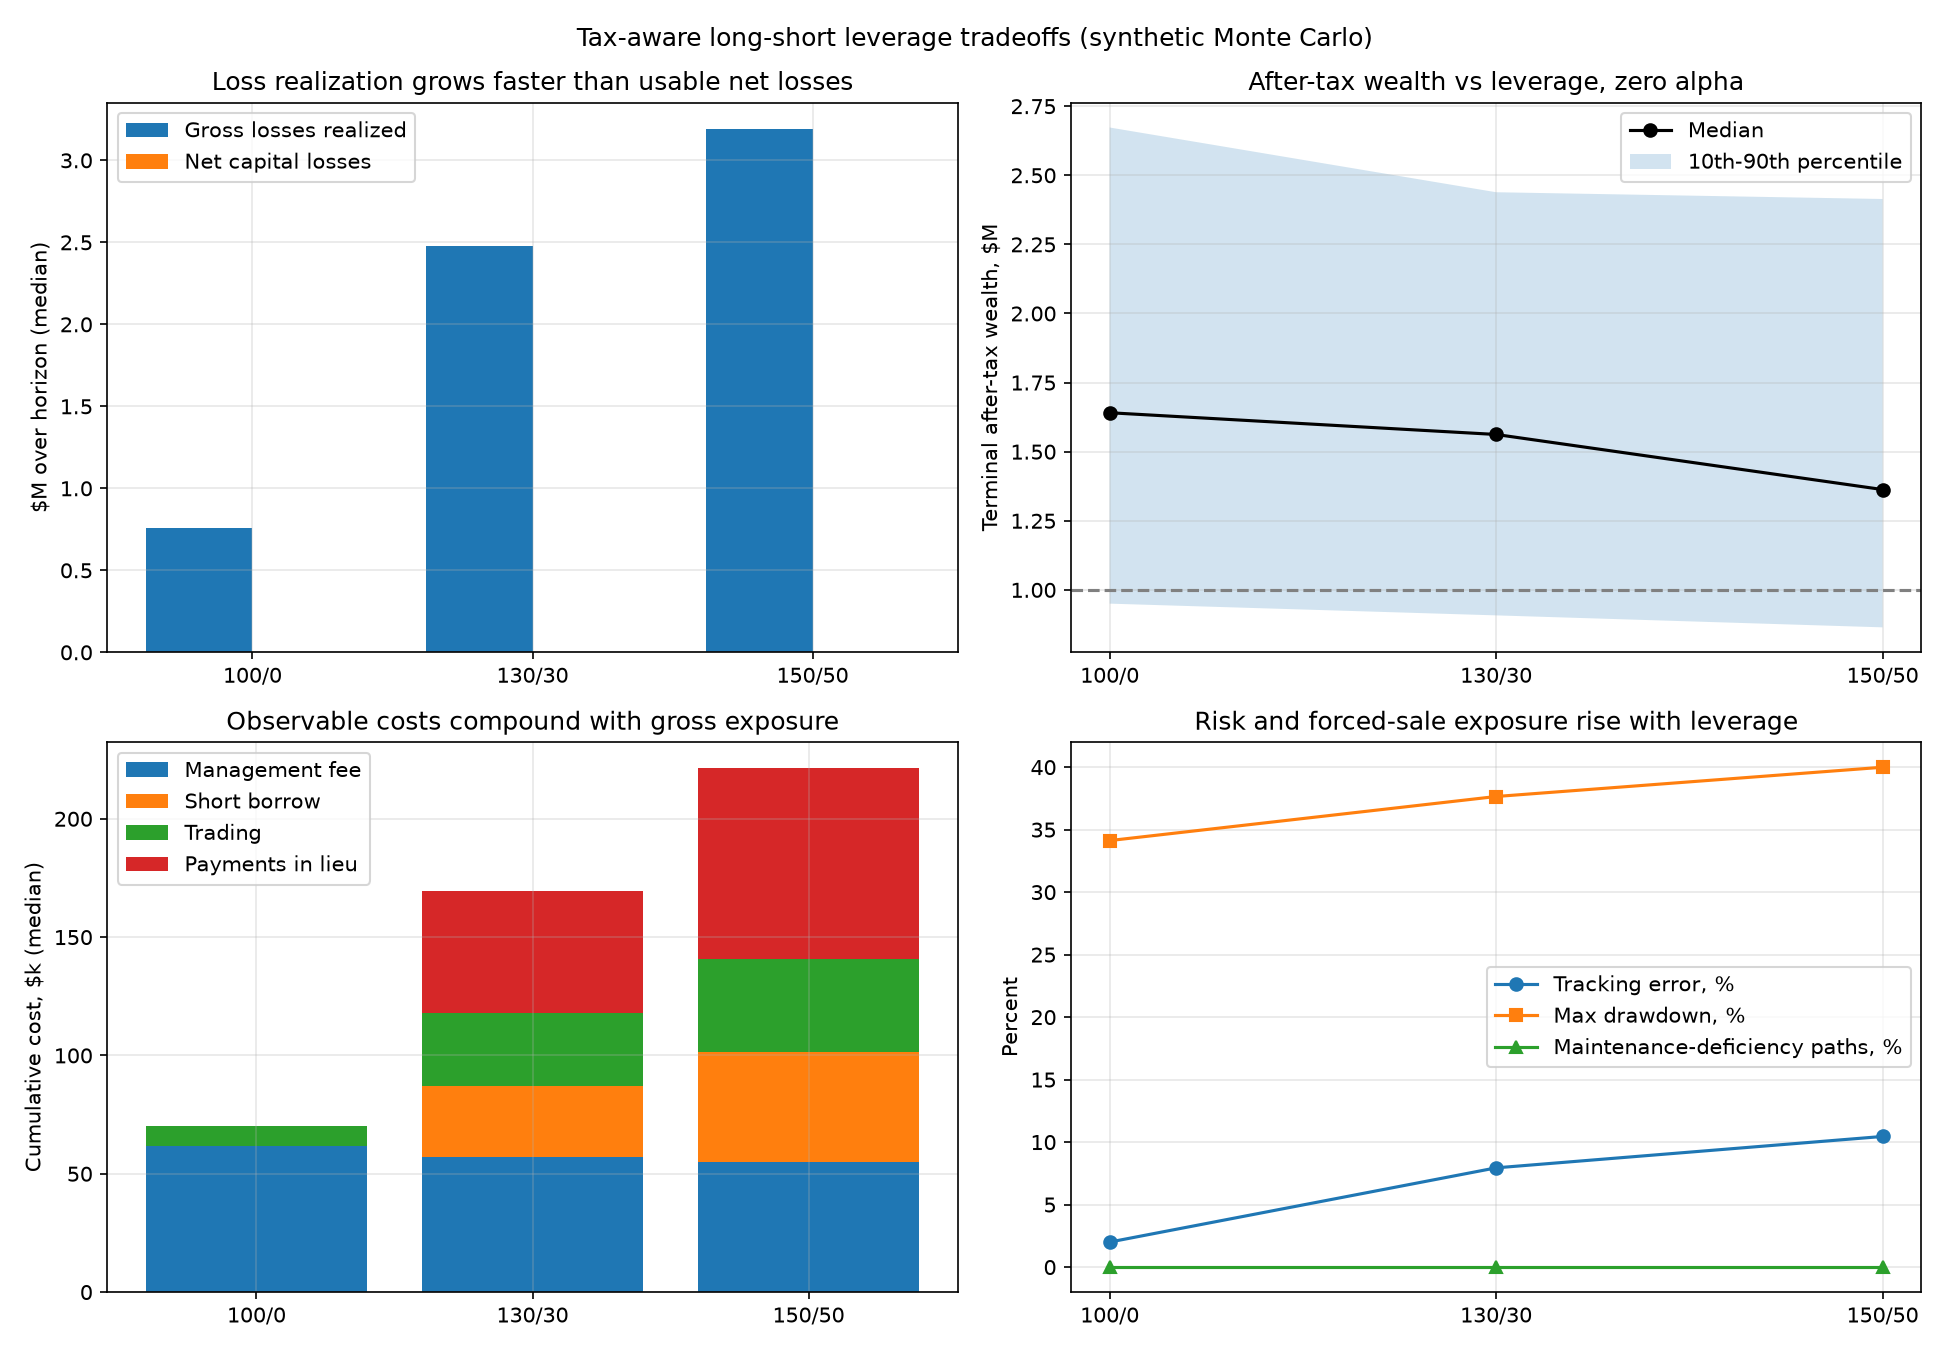

In [ ]:
import tempfile
from pathlib import Path

from IPython.display import Image

from talsim.plotting import four_panel

png = Path(tempfile.mkdtemp()) / "leverage_sweep.png"
four_panel(sweeps, png)
Image(filename=str(png), width=900)

## 5. What-if: an outside gain event

Harvested losses are only worth something when there is a gain to offset. `outside_st_gain_events` maps a zero-based year index to a one-off short-term gain. Compare three 130/30 cases on the same 40 seeds: no outside gains, the default $100k every year, and a single $500k gain in year 3 with no annual gains. These cases, plus two more, are available as `talsim.cli.SCENARIOS`.

In [ ]:
cases = {
    "no outside gains": {"outside_st_gains_annual": 0.0},
    "annual $100k": {},
    "$500k in year 3 only": {
        "outside_st_gains_annual": 0.0,
        "outside_st_gain_events": {2: 500_000.0},
    },
}
metrics = ["ending_after_tax_wealth", "tax_benefit_used", "liquidation_tax", "unused_loss_carry"]

what_if = {}
for label, overrides in cases.items():
    case_cfg = dataclasses.replace(cfg, **overrides)
    sweep = run_sweep(case_cfg, ["130/30"], n_paths=40, base_seed=7)[0]
    what_if[label] = {m: sweep.median(m) for m in metrics}

pd.DataFrame(what_if).round(0)

,no outside gains,annual $100k,$500k in year 3 only
ending_after_tax_wealth,1490122.0,1562302.0,1519915.0
tax_benefit_used,7956.0,166089.0,61998.0
liquidation_tax,89259.0,119422.0,97608.0
unused_loss_carry,-0.0,-0.0,-0.0


## 6. Margin and feasibility

Each book is checked against FINRA-style maintenance requirements at inception. A book that cannot be held at its nominal size is scaled down (`extension_scale` below 1) while preserving net exposure, so `feasible_at_inception` is `False` and average exposures fall short of the preset. Along the path, the default `margin_response="deleverage"` shrinks the long-short extension on a maintenance deficiency; `margin_response="flag"` records the deficiency instead.

In [ ]:
from talsim import BOOK_PRESETS

margin_fields = [
    "feasible_at_inception",
    "extension_scale",
    "avg_long_exposure",
    "avg_short_exposure",
    "min_margin_excess_ratio",
    "deleverage_events",
    "maintenance_deficiency_observed",
]
rows = {}
for book in BOOK_PRESETS:
    r = run_path(cfg.with_book(book), seed=7)
    rows[book] = {name: getattr(r, name) for name in margin_fields}

pd.DataFrame(rows)

,100/0,130/30,150/50,200/100,250/150
feasible_at_inception,True,True,True,True,False
extension_scale,1.0,1.0,1.0,1.0,0.884848
avg_long_exposure,1.044096,1.308587,1.50904,2.008578,2.334085
avg_short_exposure,0.0,0.313001,0.512274,1.003434,1.333222
min_margin_excess_ratio,0.71978,0.569907,0.463531,0.191783,0.013065
deleverage_events,0,0,0,0,0
maintenance_deficiency_observed,False,False,False,False,False


## 7. Reproducibility

A path is a pure function of the config and the seed. `path_frame` gives one row per path with its seed, so any statistic in a summary can be recomputed. The `talsim sweep` and `talsim scenarios` commands write the summary CSV, the path-level CSV, and a `*_manifest.json` recording the package version, git commit, Python and NumPy versions, every config, and SHA-256 checksums of the outputs.

In [ ]:
from talsim.cli import path_frame

print("same config and seed reproduce the result:", run_path(cfg, seed=7) == result)

frame = path_frame(sweeps, base_seed=7)
frame[["book", "path", "seed", "ending_after_tax_wealth", "tax_benefit_used"]].head(6)

same config and seed reproduce the result: True


,book,path,seed,ending_after_tax_wealth,tax_benefit_used
0,100/0,0,7,1.175866e+06,134075.599769
1,100/0,1,8,1.540464e+06,176829.811413
2,100/0,2,9,1.276064e+06,103163.488621
3,100/0,3,10,7.830680e+05,252152.890892
4,100/0,4,11,2.348791e+06,86273.577021
5,100/0,5,12,2.803592e+06,60969.634850


From a shell, the equivalent of the sweep above at README scale is:

```bash
talsim sweep --paths 200 --seed 7 --out results/
talsim scenarios --paths 100 --seed 7 --out results/
```

## 8. Caveats and links

Read the README section "Remaining simplifications" before citing any number. In short: one wash group per (side, asset) with no household scope; short-sale results treated as short-term; Gaussian returns per step with no jumps, corporate actions, borrow recalls, or capacity limits; a heuristic trading policy rather than a constrained optimizer; federal tax only; and tax savings held in a zero-return side account.

- API documentation: https://engineerinvestor.github.io/talsim/
- Repository and README: https://github.com/engineerinvestor/talsim
- Simplifications: https://github.com/engineerinvestor/talsim#remaining-simplifications-read-before-citing-any-number
- Issues: https://github.com/engineerinvestor/talsim/issues